In [1]:
import numpy as np
import jax.numpy as jnp
import scipy.constants as C
import matplotlib.pyplot as plt
import os
from read_write import  read_nc,read_sdf
import pandas as pd
from plot.plot_1D import plot_multiple_1D_fields, plot_twinx

In [2]:
working_dir='/scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/L+D=0.2'

In [3]:
theta_degree=45
theta_rad=np.radians(theta_degree)

laser_lambda = 0.875*C.micron		# Laser wavelength
laser_f0=1/laser_lambda
laser_k0=2*C.pi*laser_f0
laser_omega0=(2*C.pi*C.speed_of_light)/(laser_lambda)
laser_T0=laser_lambda/C.speed_of_light
laser_Bc=(C.m_e*laser_omega0)/(C.elementary_charge)
laser_Ec=laser_Bc*C.speed_of_light   #4.013376e+12V/m
laser_Sc=C.epsilon_0*C.speed_of_light*laser_Ec**2/2   #Sc=ε0·c·Ec^2/2=Ec·Bc/(2*μ0)   1.327e+18 W/m^2
laser_Nc=laser_omega0**2*C.m_e*C.epsilon_0/C.elementary_charge**2


target_N=200
plasma_cutoff_order=jnp.sqrt(target_N/(np.cos(theta_rad))**3)

laser_lambda_M=laser_lambda/np.cos(theta_rad)
laser_T0_M=laser_lambda_M/C.speed_of_light
laser_f0_M=laser_f0*np.cos(theta_rad)
laser_k0_M=laser_k0*np.cos(theta_rad)
laser_Bc_M=laser_Bc*np.cos(theta_rad)
laser_Ec_M=laser_Ec*np.cos(theta_rad)
laser_Sc_M=laser_Sc*np.cos(theta_rad)**2

In [4]:

field_dict_list=[]
dirs = [entry.name for entry in os.scandir(working_dir) if entry.is_dir()]
for dir in dirs:
    data_dict=read_sdf(os.path.join(working_dir,dir,'fields00000.sdf'),block_name_list=['Derived_Number_Density_Electron'])
    field_dict_list.append(
        {
            'field':data_dict['Derived_Number_Density_Electron']*np.cos(theta_rad)/laser_Nc,
            'label':dir,
        }
    )
    x_coordinate=data_dict['x']


Reading file /scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/L+D=0.2/L_front=0.05,L_rear=0.05/fields00000.sdf
t() = time
bx(200000,) = bx
by(200000,) = by
bz(200000,) = bz
ex(200000,) = ex
ey(200000,) = ey
ez(200000,) = ez
x(200001,) = grid
xc(200000,) = grid_mid
x,shape=(200000,)
Derived_Number_Density_Electron,shape=(200000,)
Reading file /scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/L+D=0.2/L_front=0.10,L_rear=0.00/fields00000.sdf
t() = time
bx(200000,) = bx
by(200000,) = by
bz(200000,) = bz
ex(200000,) = ex
ey(200000,) = ey
ez(200000,) = ez
x(200001,) = grid
xc(200000,) = grid_mid
x,shape=(200000,)
Derived_Number_Density_Electron,shape=(200000,)
Reading file /scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/L+D=0.2/L_front=0.00,L_rear=0.00/fields00000.sdf
t() = time
bx(200000,) = bx
by(200000,) = by
bz(200000,) = bz
ex(200000,) = ex
ey(200000,) = ey
ez(200000,) = ez
x(200001,) = grid
xc(200000,) = grid_mid
x,shape=(200000,)
Derived_Number_Density_Electron,shape=(200000,)
Reading file /sc

{'fig': <Figure size 800x600 with 1 Axes>,
 'ax_main': <Axes: xlabel='x/λ0', ylabel='Ne/Nc'>}

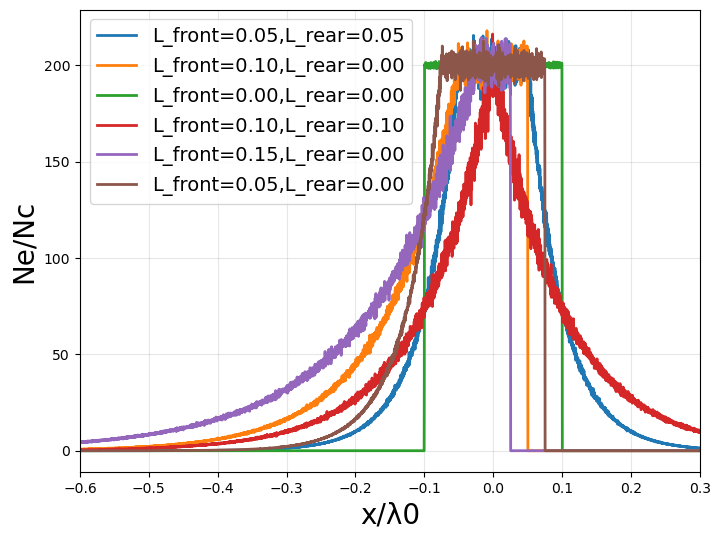

: 

In [ ]:
plot_multiple_1D_fields(
    coordinate=x_coordinate/laser_lambda,
    field_dict_list=field_dict_list,
    xlabel='x/λ0',ylabel='Ne/Nc',
    xmin=-0.6,xmax=0.3,
    )



In [28]:
incident=pd.read_hdf(os.path.join(working_dir,'all_collision','cpl=5000,ppl=2000','spectrum.hdf5'),key='Field_spectrum_square_incident')
F_5000_all=pd.read_hdf(os.path.join(working_dir,'all_collision','cpl=5000,ppl=2000','spectrum.hdf5'),key='Field_spectrum_square_transmission')
F_5000_EE=pd.read_hdf(os.path.join(working_dir,'EE_collision','cpl=5000,ppl=2000','spectrum.hdf5'),key='Field_spectrum_square_transmission')
F_5000_no=pd.read_hdf(os.path.join(working_dir,'no_collision','cpl=5000,ppl=2000','spectrum.hdf5'),key='Field_spectrum_square_transmission')
F_2000_all=pd.read_hdf(os.path.join(working_dir,'all_collision','cpl=2000,ppl=800','spectrum.hdf5'),key='Field_spectrum_square_transmission')
F_2000_EE=pd.read_hdf(os.path.join(working_dir,'EE_collision','cpl=2000,ppl=800','spectrum.hdf5'),key='Field_spectrum_square_transmission')
F_2000_no=pd.read_hdf(os.path.join(working_dir,'no_collision','cpl=2000,ppl=800','spectrum.hdf5'),key='Field_spectrum_square_transmission')

{'fig': <Figure size 800x600 with 1 Axes>,
 'ax_main': <Axes: title={'center': 'transmission spectrum'}, xlabel='kx/k0', ylabel='I(kx)/I0'>}

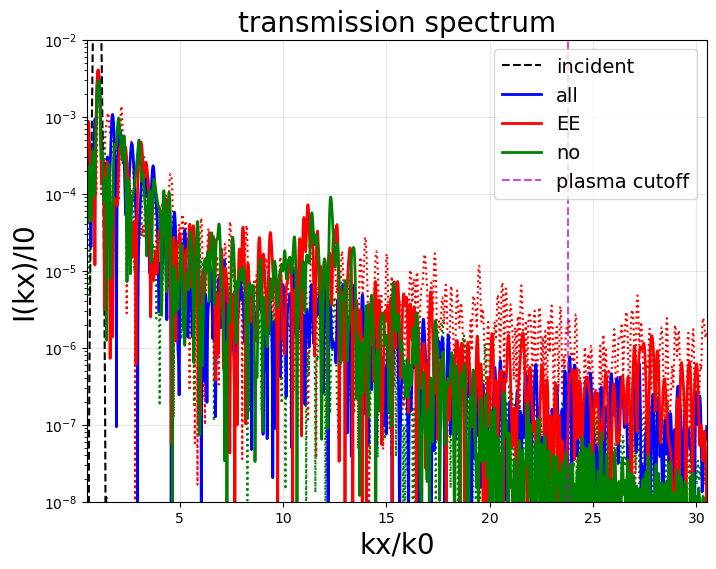

In [30]:
plot_multiple_1D_fields(
    coordinate=F_5000_all.loc[:,'kx/k0'],
    field_dict_list=[
        #{'field':F_2000_all.loc[:,'I(kx)/I0'],'linestyle':'dotted','color':'b','linewidth':1.5},
        {'field':F_2000_EE.loc[:,'I(kx)/I0'],'linestyle':'dotted','color':'r','linewidth':1.5},
        {'field':F_2000_no.loc[:,'I(kx)/I0'],'linestyle':'dotted','color':'g','linewidth':1.5},
        {'field':incident.loc[:,'I(kx)/I0'],'linestyle':'--','label':'incident','color':'k','linewidth':1.5},
        {'field':F_5000_all.loc[:,'I(kx)/I0'],'linestyle':'-','label':'all','color':'b','linewidth':2},
        {'field':F_5000_EE.loc[:,'I(kx)/I0'],'linestyle':'-','label':'EE','color':'r','linewidth':2},
        {'field':F_5000_no.loc[:,'I(kx)/I0'],'linestyle':'-','label':'no','color':'g','linewidth':2},

    ],
    axvline_dict_list=[
        {'x':plasma_cutoff_order,'linestyle':'--','label':'plasma cutoff','color':'m','alpha':0.7,'linewidth':1.5},
    ],
    xmin=0.5,xmax=30.5,xlabel='kx/k0',
    ymin=1e-8,ymax=1e-2,ylabel='I(kx)/I0',yscale='log',
    name='transmission spectrum'
    )

In [4]:
S_all_5000=pd.read_hdf(os.path.join(working_dir,'all_collision','cpl=5000,ppl=2000','final_field.hdf5'),key='Sx_[3,+∞)')
S_EE_5000=pd.read_hdf(os.path.join(working_dir,'EE_collision','cpl=5000,ppl=2000','final_field.hdf5'),key='Sx_[3,+∞)')
S_no_5000=pd.read_hdf(os.path.join(working_dir,'no_collision','cpl=5000,ppl=2000','final_field.hdf5'),key='Sx_[3,+∞)')
S_all_2000=pd.read_hdf(os.path.join(working_dir,'all_collision','cpl=2000,ppl=800','final_field.hdf5'),key='Sx_[3,+∞)')
S_EE_2000=pd.read_hdf(os.path.join(working_dir,'EE_collision','cpl=2000,ppl=800','final_field.hdf5'),key='Sx_[3,+∞)')
S_no_2000=pd.read_hdf(os.path.join(working_dir,'no_collision','cpl=2000,ppl=800','final_field.hdf5'),key='Sx_[3,+∞)')

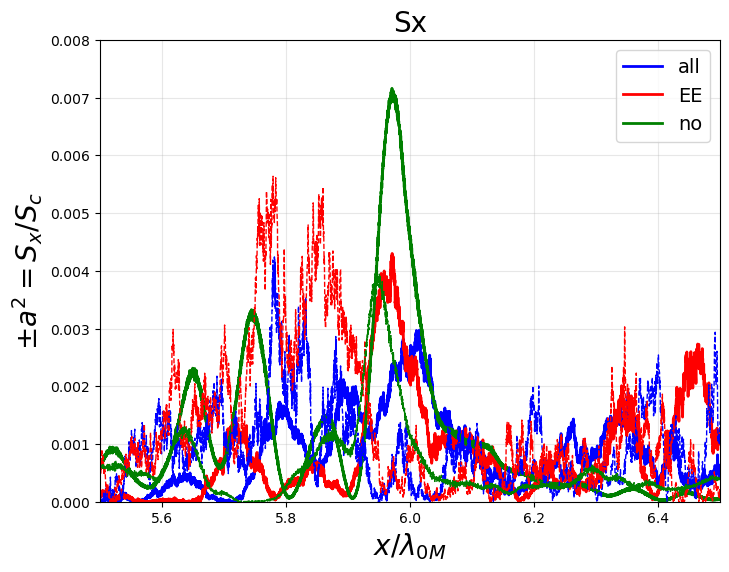

In [11]:
ax_main=plot_multiple_1D_fields(
    coordinate=S_all_5000.index/laser_lambda_M,
    field_dict_list=[
        {'field':S_all_5000.to_numpy()/laser_Sc_M, 'label':'all', 'color':'b','linewidth':2}, 
        #{'field':S_all_2000.to_numpy()/laser_Sc_M,  'color':'b','linestyle':'--','linewidth':1}, 
        {'field':S_EE_5000.to_numpy()/laser_Sc_M, 'label':'EE', 'color':'r','linewidth':2}, 
        #{'field':S_EE_2000.to_numpy()/laser_Sc_M,  'color':'r','linestyle':'--','linewidth':1}, 
        {'field':S_no_5000.to_numpy()/laser_Sc_M, 'label':'no', 'color':'g','linewidth':2}, 
        #{'field':S_no_2000.to_numpy()/laser_Sc_M,  'color':'k','linestyle':'--','linewidth':1},
    ],
    xmin=-9,xmax=-4,
    xlabel=r'$x/\lambda_{0M}$',ylabel=r'$±a^2=S_x/S_{c}$',name='Sx',
    )['ax_main']
ax_main=plot_multiple_1D_fields(
    ax=ax_main,
    coordinate=S_all_2000.index/laser_lambda_M,
    field_dict_list=[
        #{'field':S_all_5000.to_numpy()/laser_Sc_M, 'label':'all', 'color':'b','linewidth':0.5}, 
        {'field':S_all_2000.to_numpy()/laser_Sc_M,  'color':'b','linestyle':'--','linewidth':1}, 
        #{'field':S_EE_5000.to_numpy()/laser_Sc_M, 'label':'EE', 'color':'r','linewidth':0.5}, 
        {'field':S_EE_2000.to_numpy()/laser_Sc_M,  'color':'r','linestyle':'--','linewidth':1}, 
        #{'field':S_no_5000.to_numpy()/laser_Sc_M, 'label':'no', 'color':'g','linewidth':0.5}, 
        {'field':S_no_2000.to_numpy()/laser_Sc_M,  'color':'g','linestyle':'--','linewidth':1},
    ],
    xmin=5.5,xmax=6.5,ymin=0,ymax=0.008,
    xlabel=r'$x/\lambda_{0M}$',ylabel=r'$±a^2=S_x/S_{c}$',name='Sx',
    )['ax_main']

In [ ]:
x=np.linspace(-5,5,100)
field1=np.sin(x)
field2=np.cos(x)
field3=np.sinh(x)
field4=np.cosh(x)
field_dict_list=[
    {'field':field1,'linestyle':'-','label':'sin(x)'},
    {'field':field2,'linestyle':'--','label':'cos(x)'},
    {'field':field3,'linestyle':'-.','label':'sinh(x)'},
    {'field':field4,'linestyle':':','label':'cosh(x)'},
]
axhline_dict_list=[
    {'y':0,'linestyle':'--','label':'y=0'},
]
axvline_dict_list=[
    {'x':0,'linestyle':'--','label':'x=0'},
]
plot_multiple_1D_fields(
    coordinate=x,
    field_dict_list=field_dict_list,
    axhline_dict_list=axhline_dict_list,
    axvline_dict_list=axvline_dict_list,
    name='1D plot test',
    ylabel='field value',xlabel='x',
    ymin=-5,ymax=5,
    working_dir='.',
    return_fig=True
)

In [ ]:
field_dict_list_1=[
    {'field':field1,'linestyle':'-','label':'sin(x)'},
    {'field':field2,'linestyle':'-.','label':'cos(x)'},
]
field_dict_list_2=[
    {'field':field3,'linestyle':'-','label':'sinh(x)'},
    {'field':field4,'linestyle':'-.','label':'cosh(x)'},
]
plot_twinx(
    coordinate=x,
    field_dict_list_1=field_dict_list_1,
    field_dict_list_2=field_dict_list_2,
    xmin=-5,xmax=5,
    xlabel='x',
    y1_label='sin',y1_scale='linear',y1_min=-5,y1_max=5,
    y2_label='sinh',y2_scale='linear',y2_min=-5,y2_max=5,
    color_1='red',color_2='blue',
    name='twinx plot test',
    working_dir='.',
)